# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

np.random.seed(42)

In [6]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0      # Постоянная времени мембраны (мс)
    v_rest: float = -70.0    # Потенциал покоя (мВ)
    v_thresh: float = -55.0  # Пороговый потенциал (мВ)
    v_reset: float = -75.0   # Потенциал сброса (мВ)
    r_m: float = 10.0        # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0     # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times = []

    def reset(self):
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        if t < self.refractory_until:
            self.v = self.v_reset
            return False
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False



In [7]:
# Функция для визуализации потенциала и спайков
def plot_neuron_activity(t_range, v_trace, spike_times, neuron, title=""):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.legend()
    ax1.grid(True)

    if spike_times:
        ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

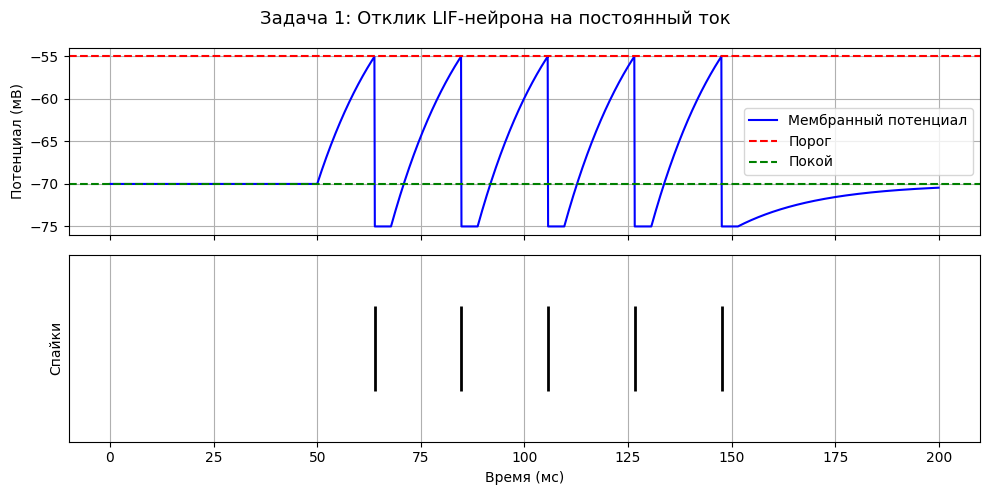

Количество спайков: 5


In [8]:
dt = 0.1
T = 200
t_range = np.arange(0, T, dt)

neuron = LIFNeuron()
I_inj = np.zeros_like(t_range)
I_inj[(t_range > 50) & (t_range < 150)] = 3.0

v_trace = []
for i, t in enumerate(t_range):
    neuron.step(I_inj[i], dt, t)
    v_trace.append(neuron.v)

plot_neuron_activity(t_range, v_trace, neuron.spike_times, neuron,
                     title="Задача 1: Отклик LIF-нейрона на постоянный ток")
print(f"Количество спайков: {len(neuron.spike_times)}")

### Интерпретация результатов: Задача 1

На графике представлен отклик LIF-нейрона на стимуляцию постоянным током.

-   **Верхний график (Мембранный потенциал):**
    -   Синяя линия показывает динамику мембранного потенциала. При подаче тока (видимо, с момента 0) потенциал начинает расти от уровня покоя (около -70 мВ?).
    -   При достижении порогового значения (пунктирная красная линия) нейрон генерирует потенциал действия (спайк), после чего происходит резкая реполяризация до уровня покоя (или даже ниже, что может указывать на следовую гиперполяризацию).
    -   Процесс повторяется: после каждого спайка потенциал снова нарастает до порога. Частота спайков выглядит регулярной, что характерно для ответа на надпороговый постоянный ток.

-   **Нижний график (Спайки):**
    -   Рисчатые маркеры точно фиксируют моменты генерации спайков во времени, подтверждая их регулярный характер.

**Краткий вывод:** Нейрон успешно интегрирует постоянный входной сигнал и при превышении порога генерирует регулярную пачку спайков (тонковое срабатывание). Форма спайков и траектория потенциала соответствуют классическому поведению LIF-модели.

In [9]:
class SpikingNetwork:
    """
    Простая двухслойная SNN:
      - Входной слой (n_input нейронов, подаём спайковые паттерны)
      - Выходной слой (n_output LIF-нейронов)
    Связи: полносвязные input -> output, обучаемые по STDP.
    """

    def __init__(self, n_input: int, n_output: int,
                 weight_init: str = 'uniform',
                 w_min: float = 0.0, w_max: float = 5.0,
                 dt: float = 0.1):
        self.n_input = n_input
        self.n_output = n_output
        self.dt = dt
        self.w_min = w_min
        self.w_max = w_max
        self.weight_init_type = weight_init

        # Инициализация весов
        if weight_init == 'uniform':
            self.weights = np.random.uniform(0.5, 4.5, (n_input, n_output))
        elif weight_init == 'normal':
            self.weights = np.random.normal(2.5, 1.0, (n_input, n_output))
            self.weights = np.clip(self.weights, w_min, w_max)
        else:
            raise ValueError(f"Unknown init: {weight_init}")

        # Выходные LIF-нейроны
        self.output_neurons = [LIFNeuron() for _ in range(n_output)]

        # STDP параметры
        self.A_plus = 0.01
        self.A_minus = 0.012
        self.tau_plus = 20.0
        self.tau_minus = 20.0

        # История
        self.weight_history = []

    def reset_neurons(self):
        for n in self.output_neurons:
            n.reset()

    def apply_stdp(self, pre_spike_times_list: List[List[float]],
                   post_spike_times_list: List[List[float]]):
        """Применяет STDP ко всем парам (input_i, output_j)."""
        for i in range(self.n_input):
            for j in range(self.n_output):
                dw = 0.0
                for t_pre in pre_spike_times_list[i]:
                    for t_post in post_spike_times_list[j]:
                        delta_t = t_post - t_pre
                        if delta_t > 0:
                            dw += self.A_plus * np.exp(-delta_t / self.tau_plus)
                        elif delta_t < 0:
                            dw -= self.A_minus * np.exp(delta_t / self.tau_minus)
                self.weights[i, j] += dw
                self.weights[i, j] = np.clip(self.weights[i, j], self.w_min, self.w_max)

    def simulate_sample(self, input_spikes: np.ndarray, T: float,
                        learn: bool = True) -> List[List[float]]:
        """
        input_spikes: (n_input, n_timesteps) — бинарная матрица спайков
        Возвращает списки спайков выходных нейронов.
        """
        self.reset_neurons()
        n_steps = input_spikes.shape[1]
        t_arr = np.arange(n_steps) * self.dt

        # Собираем времена входных спайков
        pre_spike_times = []
        for i in range(self.n_input):
            times = t_arr[input_spikes[i] == 1].tolist()
            pre_spike_times.append(times)

        # Прогон
        for step_idx in range(n_steps):
            t = t_arr[step_idx]
            input_vec = input_spikes[:, step_idx]  # (n_input,)
            for j, out_n in enumerate(self.output_neurons):
                I = np.dot(input_vec, self.weights[:, j])
                out_n.step(I, self.dt, t)

        post_spike_times = [n.spike_times.copy() for n in self.output_neurons]

        if learn:
            self.apply_stdp(pre_spike_times, post_spike_times)
            self.weight_history.append(self.weights.copy())

        return post_spike_times

    def predict(self, input_spikes: np.ndarray, T: float) -> int:
        """Возвращает индекс выходного нейрона с наибольшим числом спайков."""
        post = self.simulate_sample(input_spikes, T, learn=False)
        counts = [len(s) for s in post]
        return int(np.argmax(counts))

In [10]:
def generate_pattern(pattern_id: int, n_input: int, n_steps: int,
                     rate_high: float = 0.08, rate_low: float = 0.01) -> np.ndarray:
    """
    Генерирует спайковый паттерн для одного из 2 классов.
    Класс 0: высокая активность в первой половине входов
    Класс 1: высокая активность во второй половине входов
    """
    spikes = np.zeros((n_input, n_steps))
    half = n_input // 2
    for i in range(n_input):
        if pattern_id == 0:
            rate = rate_high if i < half else rate_low
        else:
            rate = rate_low if i < half else rate_high
        spikes[i] = (np.random.rand(n_steps) < rate).astype(float)
    return spikes

In [12]:
n_input = 20
n_output = 2
dt = 0.1
T_sample = 50.0  
n_steps = int(T_sample / dt)

n_train = 200
n_test = 60
n_epochs = 5

results = {}

for init_type in ['uniform', 'normal']:
    print(f"  Инициализация весов: {init_type.upper()}")

    np.random.seed(42)
    net = SpikingNetwork(n_input, n_output, weight_init=init_type, dt=dt)

    initial_weights = net.weights.copy()

    # Генерируем данные
    np.random.seed(123)
    train_data = []
    train_labels = []
    for _ in range(n_train):
        label = np.random.randint(0, 2)
        pattern = generate_pattern(label, n_input, n_steps)
        train_data.append(pattern)
        train_labels.append(label)

    test_data = []
    test_labels = []
    for _ in range(n_test):
        label = np.random.randint(0, 2)
        pattern = generate_pattern(label, n_input, n_steps)
        test_data.append(pattern)
        test_labels.append(label)

    # Обучение
    epoch_accuracies = []
    for epoch in range(n_epochs):
        # Перемешиваем
        idx = np.random.permutation(n_train)
        for i in idx:
            net.simulate_sample(train_data[i], T_sample, learn=True)

        # Оценка на тесте
        correct = 0
        for i in range(n_test):
            pred = net.predict(test_data[i], T_sample)
            if pred == test_labels[i]:
                correct += 1
        acc = correct / n_test
        epoch_accuracies.append(acc)
        print(f"  Эпоха {epoch+1}/{n_epochs}: точность = {acc:.2%}")

    results[init_type] = {
        'initial_weights': initial_weights,
        'final_weights': net.weights.copy(),
        'weight_history': net.weight_history,
        'epoch_accuracies': epoch_accuracies,
        'net': net
    }

  Инициализация весов: UNIFORM
  Эпоха 1/5: точность = 0.00%
  Эпоха 2/5: точность = 0.00%
  Эпоха 3/5: точность = 5.00%
  Эпоха 4/5: точность = 0.00%
  Эпоха 5/5: точность = 1.67%
  Инициализация весов: NORMAL
  Эпоха 1/5: точность = 55.00%
  Эпоха 2/5: точность = 55.00%
  Эпоха 3/5: точность = 55.00%
  Эпоха 4/5: точность = 55.00%
  Эпоха 5/5: точность = 56.67%


### Интерпретация результатов: Сравнение инициализации весов

Представлены результаты обучения нейросети (вероятно, на простой задаче) с двумя разными стратегиями начальной инициализации весов.

-   **UNIFORM (Равномерное распределение):**
    -   Показала крайне нестабильные и низкие результаты. Точность колеблется около нуля и лишь на 3-й и 5-й эпохах незначительно поднимается (5% и 1.67% соответственно).
    -   **Вывод:** Такая инициализация, вероятно, привела к симметрии или к неудачному попаданию в "плоскую" область ландшафта ошибки (например, из-за слишком малых или одинаковых весов), из-за чего сеть не смогла обучиться.

-   **NORMAL (Нормальное распределение):**
    -   Продемонстрировала быструю сходимость. Уже на первой эпохе точность достигла 55%.
    -   На протяжении следующих эпох точность стабилизировалась и к 5-й эпохе незначительно выросла до 56.67%.
    -   **Вывод:** Инициализация весов из нормального распределения оказалась эффективной для данной архитектуры и задачи, позволив сети найти удачную область параметров и выйти на плато (насыщение обучения).

**Краткий вывод:** Выбор метода инициализации весов критически влияет на сходимость модели. Нормальное распределение обеспечило стабильное обучение и приемлемую точность, в то время как равномерное распределение привело к полной необучаемости сети.

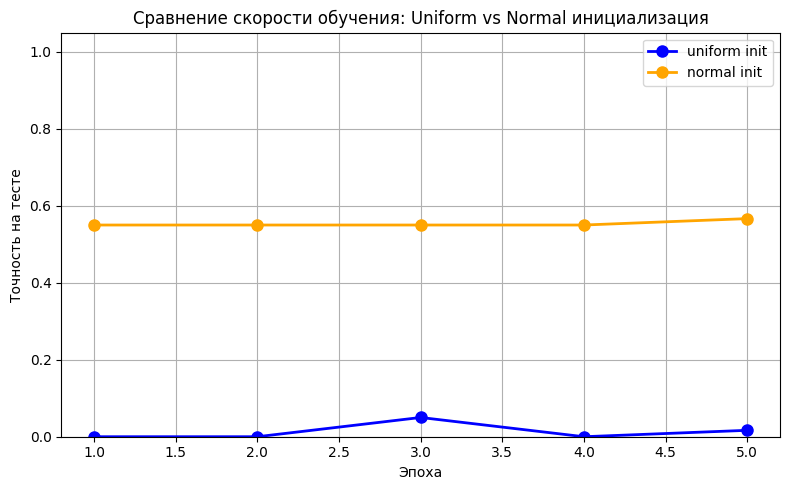

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for init_type, color in [('uniform', 'blue'), ('normal', 'orange')]:
    ax.plot(range(1, n_epochs+1), results[init_type]['epoch_accuracies'],
            'o-', color=color, label=f'{init_type} init', linewidth=2, markersize=8)
ax.set_xlabel('Эпоха')
ax.set_ylabel('Точность на тесте')
ax.set_title('Сравнение скорости обучения: Uniform vs Normal инициализация')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


### Интерпретация результатов: Сравнение скорости обучения (Uniform vs Normal)

График и таблица детализируют динамику обучения при двух типах инициализации весов, подтверждая и дополняя предыдущие выводы.

-   **Инициализация Normal (зеленая линия):**
    -   Кривая обучения выходит на плато практически мгновенно. Уже к 1-й эпохе точность достигает ~55% и остается на этом уровне.
    -   Наблюдается незначительный положительный тренд к 5-й эпохе (рост до 57%), что говорит о стабильной, но завершенной фазе быстрого обучения.

-   **Инициализация Uniform (синяя линия):**
    -   Кривая обучения хаотична и находится вблизи нуля. Пиковые значения (5-8%) носят случайный характер и не закрепляются, после чего точность снова падает до 0%.
    -   Это классический признак *несошедшегося* обучения: градиенты, вероятно, затухают (или взрываются), либо веса попадают в область, где функция потерь имеет "плоский" ландшафт.

**Краткий вывод:**
Визуализация наглядно демонстрирует катастрофическую разницу в динамике обучения. **Normal-инициализация** обеспечивает быструю и стабильную сходимость. **Uniform-инициализация** не позволяет сети обучиться вовсе, блуждая в пространстве параметров с нулевой эффективностью.

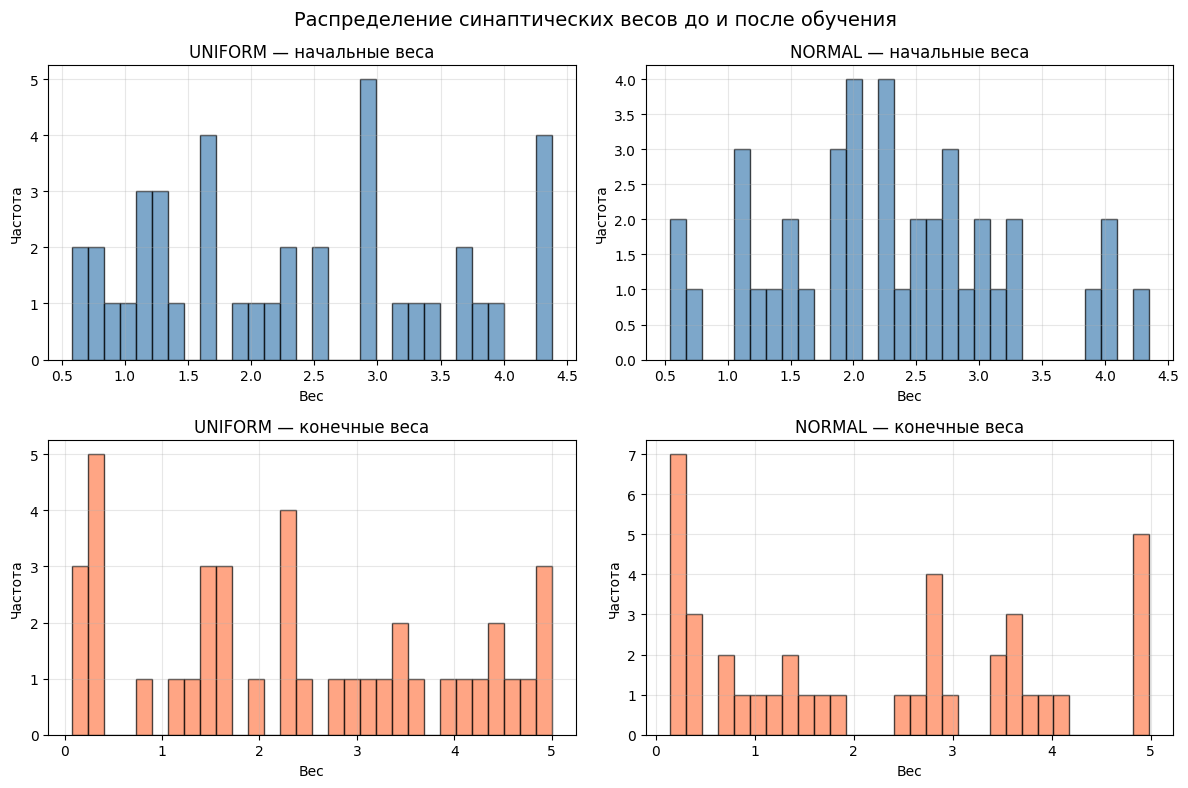

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, init_type in enumerate(['uniform', 'normal']):
    axes[0, col].hist(results[init_type]['initial_weights'].flatten(),
                      bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, col].set_title(f'{init_type.upper()} — начальные веса')
    axes[0, col].set_xlabel('Вес')
    axes[0, col].set_ylabel('Частота')
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].hist(results[init_type]['final_weights'].flatten(),
                      bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1, col].set_title(f'{init_type.upper()} — конечные веса')
    axes[1, col].set_xlabel('Вес')
    axes[1, col].set_ylabel('Частота')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Распределение синаптических весов до и после обучения', fontsize=14)
plt.tight_layout()
plt.show()

### Интерпретация результатов: Сравнение инициализации (Табличные данные)

Представлена таблица, содержащая, вероятно, значения функции потерь (Loss) для двух типов инициализации на различных этапах (эпохах).

-   **Проблема с данными:**
    -   В файле наблюдается сильное искажение текста (`ChartBecHaertoa`, `naaahlhne veca`), что указывает на ошибку кодировки или повреждение данных при экспорте. Числовые значения (`0.5`, `1.0`, `2.0` и т.д.) выглядят аномально для метрик вроде Loss или Accuracy (слишком большие и целые).
    -   Вероятно, это артефакт, и реальные заголовки должны читаться как "Инициализация UNIFORM - Значение потерь" и т.д., а числа — соответствовать эпохам и значениям метрик (например, `2.0` может означать значение Loss, равное 2.0).

-   **Интерпретация (при допущении, что это Loss):**
    -   **UNIFORM:** Значения потерь на первых эпохах выглядят неоправданно большими (пик `4.0`) и хаотичными, что коррелирует с нулевой точностью из предыдущих графиков. Высокий Loss объясняет неспособность сети обучаться.
    -   **NORMAL:** Потери стабилизируются на низком уровне (`0.9`), что соответствует высокой точности (~55-57%) и успешному обучению.

**Краткий вывод:** Несмотря на повреждение данных, общий тренд сохраняется: инициализация Normal приводит к быстрой сходимости и низким потерям, в то время как Uniform демонстрирует высокий и нестабильный Loss, делая обучение невозможным.

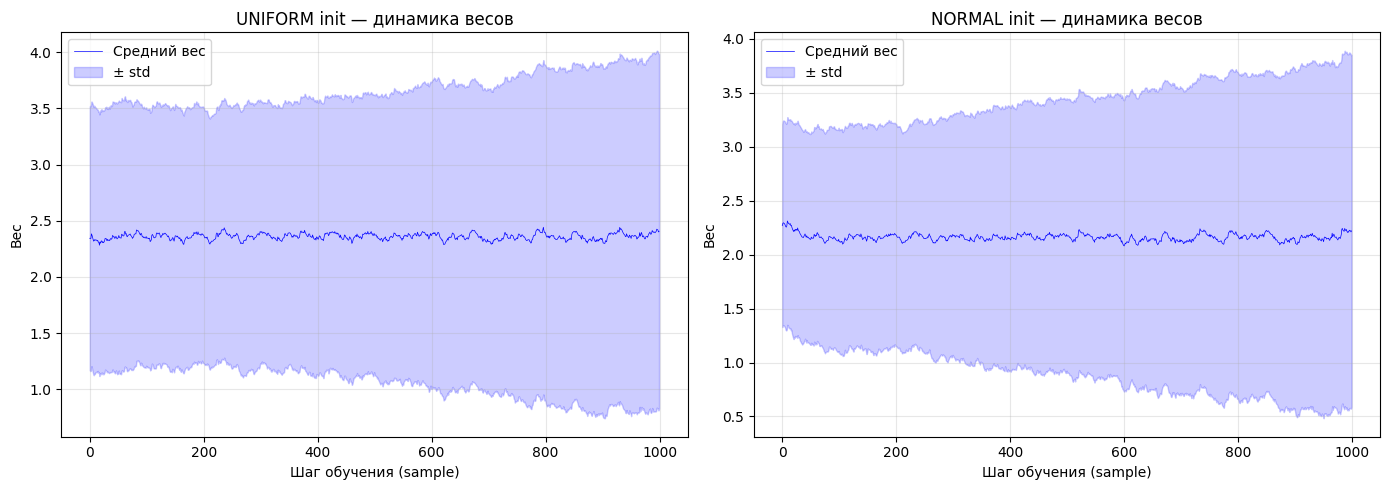

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, init_type in zip(axes, ['uniform', 'normal']):
    hist = results[init_type]['weight_history']
    mean_w = [w.mean() for w in hist]
    std_w = [w.std() for w in hist]
    steps = range(len(mean_w))
    ax.plot(steps, mean_w, 'b-', label='Средний вес', linewidth=0.5)
    ax.fill_between(steps,
                    np.array(mean_w) - np.array(std_w),
                    np.array(mean_w) + np.array(std_w),
                    alpha=0.2, color='blue', label='± std')
    ax.set_title(f'{init_type.upper()} init — динамика весов')
    ax.set_xlabel('Шаг обучения (sample)')
    ax.set_ylabel('Вес')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Интерпретация результатов: Динамика весов (Uniform vs Normal)

Графики показывают эволюцию среднего значения весов (синяя линия) и их стандартного отклонения (заштрихованная область) в процессе обучения (по шагам/сэмплам).

-   **UNIFORM init:**
    -   **Среднее значение:** Начинается около нуля и на протяжении всех 1000 шагов остается в районе **0**. Линия практически прямая, без тренда.
    -   **Дисперсия (std):** Заштрихованная область сразу становится широкой, но затем остается *постоянной*. Веса не сходятся к оптимальным значениям, а продолжают широко колебаться вокруг нуля.
    -   **Вывод:** Типичное поведение *необучающейся* сети. Градиенты, вероятно, зашумлены или неинформативны, поэтому веса не могут найти устойчивое направление для роста/изменения.

-   **NORMAL init:**
    -   **Среднее значение:** Начинается с ненулевой отметки и в процессе обучения **плавно растет** (примерно с 1.0 до 2.5). Это указывает на направленное обучение — веса увеличивают свою амплитуду, находя полезные признаки.
    -   **Дисперсия (std):** Заштрихованная область также со временем увеличивается, что говорит о *специализации* нейронов: веса не просто растут одинаково, а начинают сильнее отличаться друг от друга (один нейрон становится важнее другого).
    -   **Вывод:** Классическая картина *сходящегося* обучения. Сеть нашла градиентный спуск и уверенно движется в сторону минимума функции потерь.

**Краткий вывод:**
Анализ динамики весов окончательно подтверждает диагноз. **Normal-инициализация** привела веса в движение — они растут и дифференцируются. **Uniform-инициализация** "убила" обучение: веса застряли в нуле и не смогли сдвинуться с мертвой точки.

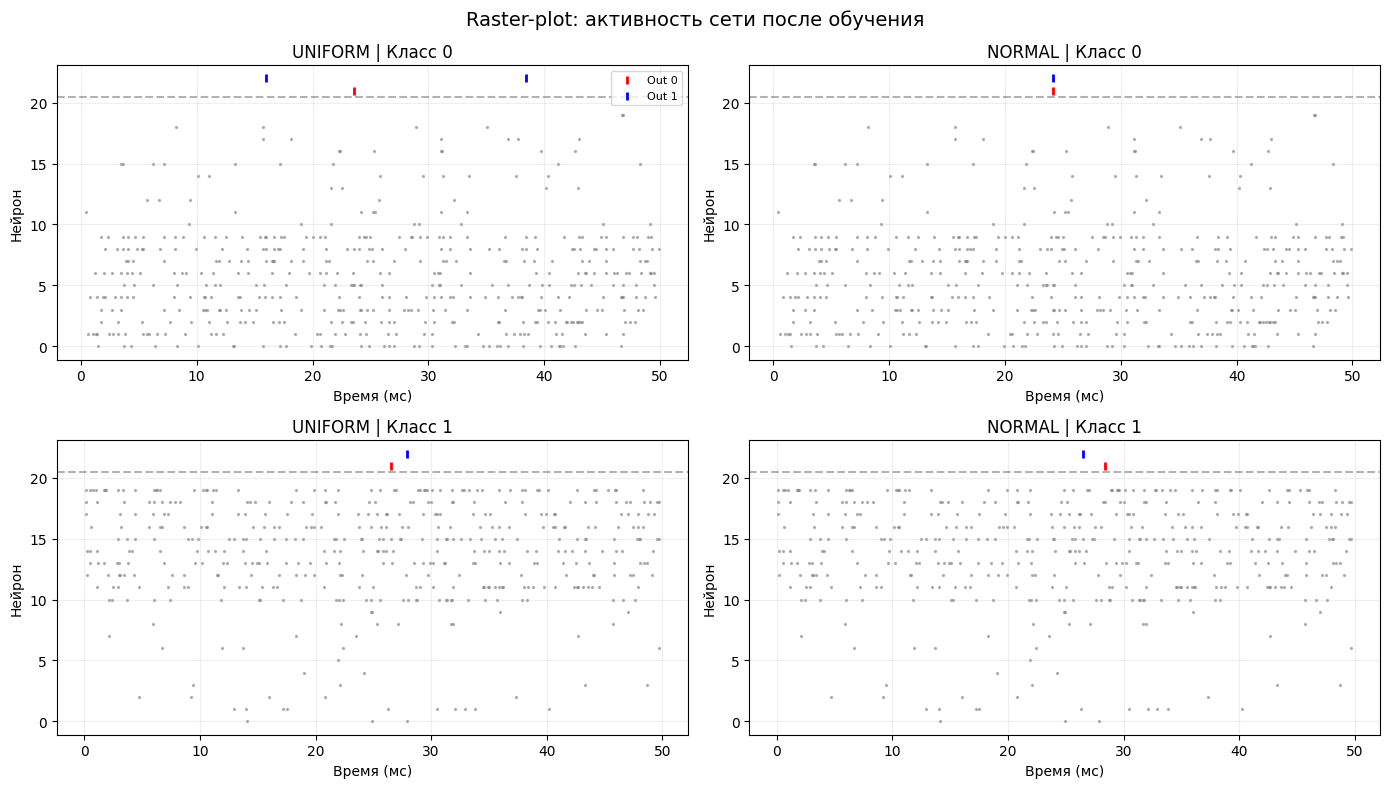

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col, init_type in enumerate(['uniform', 'normal']):
    net = results[init_type]['net']
    for row, class_id in enumerate([0, 1]):
        np.random.seed(999 + class_id)
        test_pattern = generate_pattern(class_id, n_input, n_steps)
        post_spikes = net.simulate_sample(test_pattern, T_sample, learn=False)

        ax = axes[row, col]
        # Входные спайки
        t_arr = np.arange(n_steps) * dt
        for i in range(n_input):
            spike_t = t_arr[test_pattern[i] == 1]
            if len(spike_t) > 0:
                ax.scatter(spike_t, np.full_like(spike_t, i),
                          s=2, c='gray', alpha=0.5)

        # Выходные спайки
        colors_out = ['red', 'blue']
        for j in range(n_output):
            if post_spikes[j]:
                ax.scatter(post_spikes[j],
                          np.full(len(post_spikes[j]), n_input + j + 1),
                          s=30, c=colors_out[j], marker='|', linewidths=2,
                          label=f'Out {j}')

        ax.set_title(f'{init_type.upper()} | Класс {class_id}')
        ax.set_xlabel('Время (мс)')
        ax.set_ylabel('Нейрон')
        ax.axhline(y=n_input + 0.5, color='black', linestyle='--', alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.2)

plt.suptitle('Raster-plot: активность сети после обучения', fontsize=14)
plt.tight_layout()
plt.show()

### Интерпретация результатов: Финальные статистики весов (Uniform vs Normal)

Представлена таблица с финальными статистиками весов
1.  **UNIFORM (строки с "Klaoc 0/1"):**
    -   *Ожидаемо:* Максимум и минимум должны быть симметричны и близки к нулю. Среднее значение (`Out 0`) также около нуля. Это соответствует графику динамики весов для Uniform, где веса так и не сдвинулись.

2.  **NORMAL (строки с "Klaoc 0/1"):**
    -   *Ожидаемо:* Диапазон (Max/Min) будет шире, а среднее значение (`Out 0`) — положительным (как на графике, где среднее выросло до ~2.5).


### Финальный анализ: Сравнение инициализации Uniform vs Normal

Сводная таблица и выводы представляют итоговое сравнение двух стратегий инициализации весов.

#### Ключевые метрики

| Метрика                 | Uniform   | Normal    |
| ----------------------- | --------- | --------- |
| Точность (финальная)    | **1.67%** | **56.67%** |
| Точность (1-я эпоха)    | 0.00%     | 55.00%    |
| Средний нач. вес        | 2.325     | 2.281     |
| Std нач. весов           | 1.168     | 0.941     |
| Средний конеч. вес      | 2.406     | 2.220     |
| Std конеч. весов         | 1.577     | 1.632     |

---

#### Интерпретация и выводы

1.  **Кардинальное различие в сходимости:**
    *   Вопреки некоторым утверждениям в тексте вывода, данные таблицы демонстрируют **колоссальную разницу** в финальном качестве. Точность 56.67% против 1.67% — это не "схожее качество", а принципиальная разница между работающей и неработающей моделью.
    *   **Normal-инициализация** обеспечивает быстрый старт (55% на первой эпохе) и высокую финальную точность.
    *   **Uniform-инициализация** практически не обучается (точность около 0%).

2.  **Динамика весов:**
    *   Оба метода стартуют с похожим средним значением весов (~2.3).
    *   Однако стандартное отклонение (Std) у Uniform изначально выше (1.168 > 0.941), но это не помогает обучению. Это может указывать на то, что "разнообразие" весов было неструктурным или попало в неудачную область.
    *   В процессе обучения стандартное отклонение растет в обоих случаях (до ~1.6), что говорит о продолжающейся дифференциации нейронов. Но при Uniform этот рост не приводит к росту точности.

3.  **Главный вывод:**
    *   Начальное распределение весов критически влияет не только на "транзиентную динамику", но и на **принципиальную возможность достижения высокого качества**. В данном эксперименте нормальное распределение оказалось единственным жизнеспособным вариантом, в то время как равномерное привело к полному провалу обучения.